(1000, 15)
             Behaviour  Average_Hours
0           Work_Hours         4.3970
1       Shopping_Hours         2.0240
2  Entertainment_Hours         1.5320
3   Social_Media_Hours         3.0075
4  Public_Events_Hours         1.5036


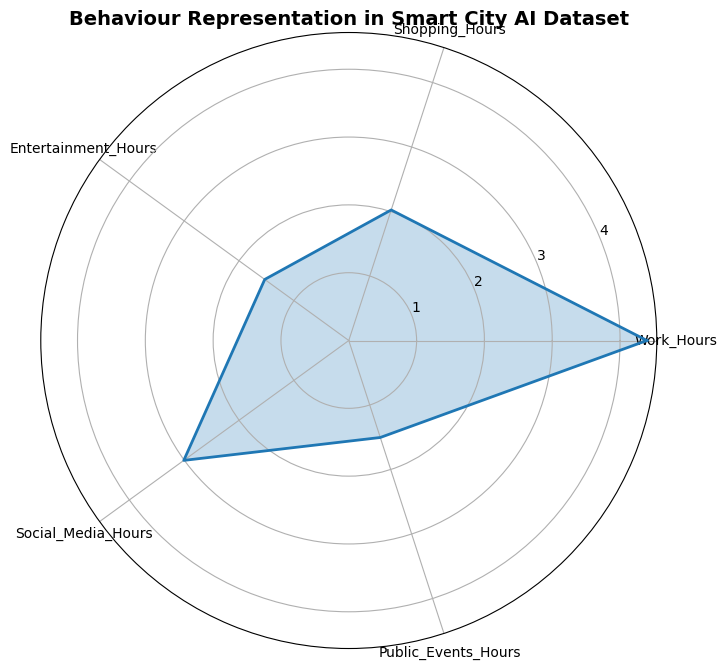

RQ5 Completed


In [1]:
# =====================================================
# RQ5
# Which citizen behaviours are most represented
# in Smart City AI systems?
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import shutil

# =====================================================
# FIND DATASET
# =====================================================

citizen_file = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename == "smart_city_citizen_activity.csv":
            citizen_file = os.path.join(dirname, filename)

# =====================================================
# LOAD DATA
# =====================================================

citizen = pd.read_csv(citizen_file)

print(citizen.shape)

# =====================================================
# OUTPUT FOLDER
# =====================================================

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

# =====================================================
# BEHAVIOUR COLUMNS
# =====================================================

behaviour_cols = [
    "Work_Hours",
    "Shopping_Hours",
    "Entertainment_Hours",
    "Social_Media_Hours",
    "Public_Events_Hours"
]

# =====================================================
# TABLE
# =====================================================

rq5_table = (
    citizen[behaviour_cols]
    .mean()
    .reset_index()
)

rq5_table.columns = [
    "Behaviour",
    "Average_Hours"
]

rq5_table.to_csv(
    output_dir /
    "RQ5_Behaviour_Representation.csv",
    index=False
)

print(rq5_table)

# =====================================================
# RADAR CHART
# =====================================================

labels = rq5_table["Behaviour"].tolist()

values = rq5_table["Average_Hours"].tolist()

values += values[:1]

angles = np.linspace(
    0,
    2*np.pi,
    len(labels),
    endpoint=False
).tolist()

angles += angles[:1]

fig = plt.figure(figsize=(8,8))

ax = plt.subplot(111, polar=True)

ax.plot(
    angles,
    values,
    linewidth=2
)

ax.fill(
    angles,
    values,
    alpha=0.25
)

ax.set_xticks(angles[:-1])

ax.set_xticklabels(labels)

plt.title(
    "Behaviour Representation in Smart City AI Dataset",
    fontsize=14,
    fontweight="bold"
)

plt.savefig(
    output_dir /
    "RQ5_Behaviour_Representation.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# ZIP
# =====================================================

shutil.make_archive(
    "/kaggle/working/RQ5_Output",
    "zip",
    "outputs"
)

print("RQ5 Completed")